## Dealing with unstructured and structured data, Data Science is a field that comprises of everything that related to data cleansing, preparation, and analysis. 

- obtaining knowledge from often enormously large data sets. 
- process include  analysis, preparing data for analysis, and presenting results to support organisational decisions

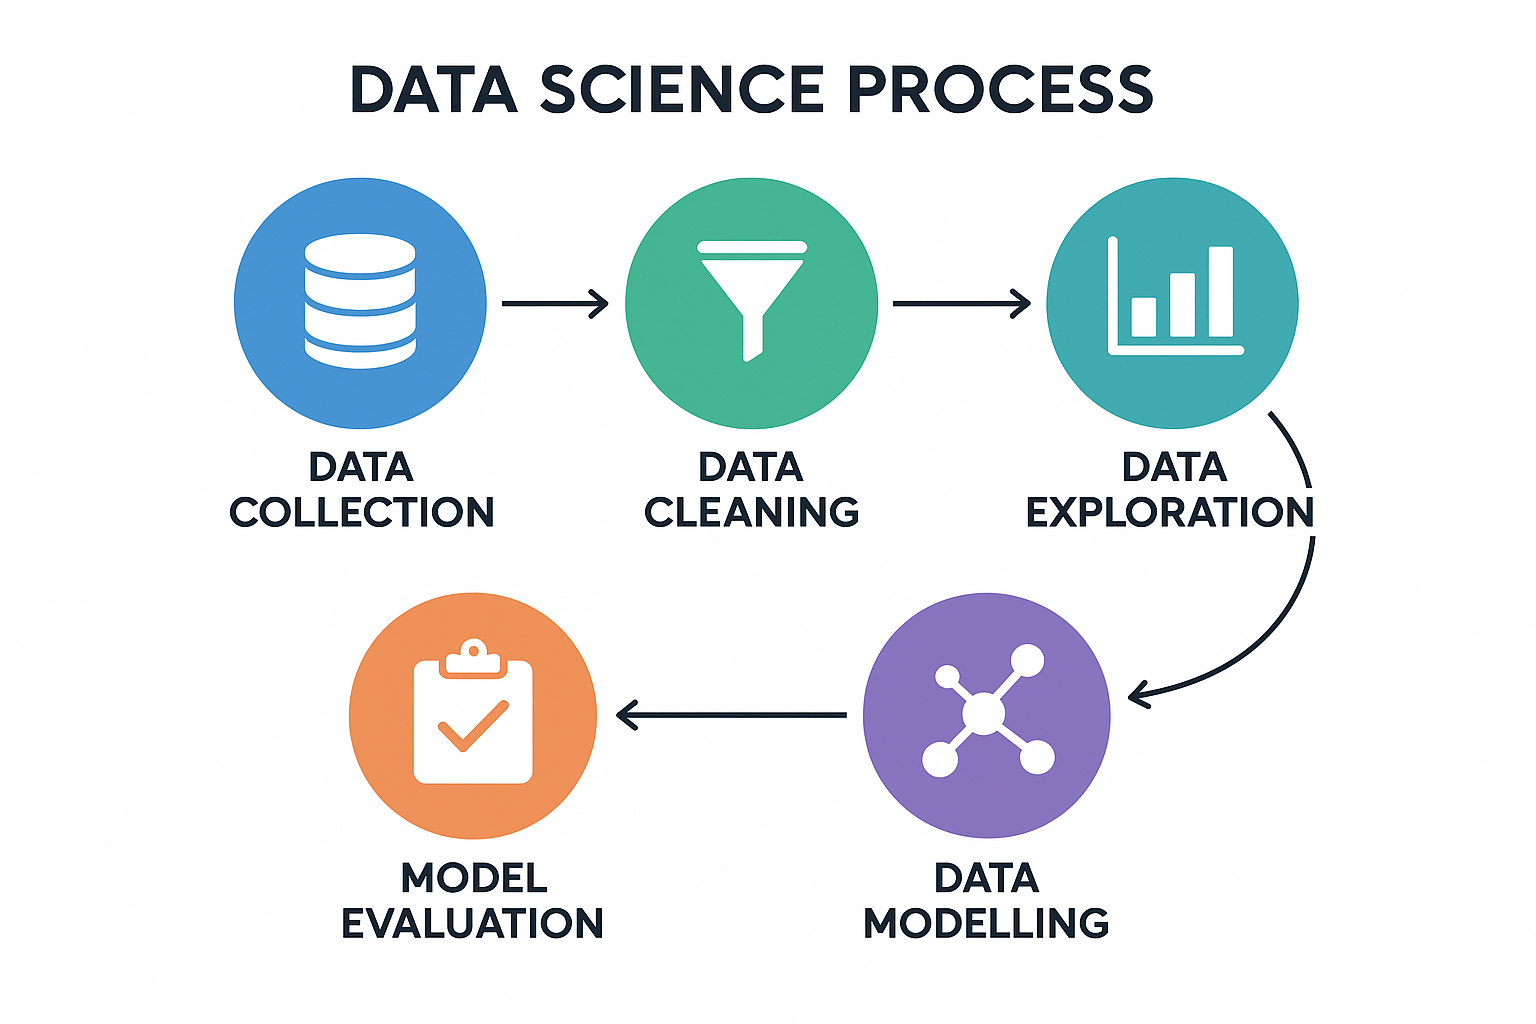


## Data Science is the combination of 
- statistics, 
- mathematics, 
- programming, 
- problem-solving, 
- capturing data in ingenious ways, the ability to look at things differently, 
- and the activity of cleansing, preparing and aligning the data. 

---+



## Use Cases for Data Science WorkFlow



| Use Case                | Problem Description                                     | Example Models          | Key Metrics            |
|-------------------------|---------------------------------------------------------|-------------------------|------------------------|
| Customer Churn          | Predict if a customer will leave a service.            | Logistic Regression,    | Precision, Recall, F1  |
| Prediction              |                                                         | Decision Trees          |                        |
|-------------------------|---------------------------------------------------------|-------------------------|------------------------|
| Product Recommendation  | Suggest products to users based on their behavior.     | Collaborative Filtering,| Mean Average Precision |
| System                  |                                                         | Content-Based Filtering |                        |
|-------------------------|---------------------------------------------------------|-------------------------|------------------------|
| House Price Prediction  | Predict house prices based on features like location.  | Linear Regression,      | RMSE, R² Score         |
|                         |                                                         | Random Forest           |                        |
|-------------------------|---------------------------------------------------------|-------------------------|------------------------|
| Fraud Detection         | Detect fraudulent transactions in financial systems.   | Random Forest, SVM,     | Precision, Recall,     |
|                         |                                                         | Neural Networks         | False Negatives        |


###  Customer Churn Prediction
- Problem Definition: Predict whether a customer will leave a service (churn) based on their historical usage data.
- Data Collection: Collect data from CRM systems, transaction logs, and support tickets.
### Data Preprocessing:
- Clean missing data.
- Standardize features like age, income, or usage duration.
### Exploratory Data Analysis (EDA):
- Analyze trends (e.g., high churn in low usage customers).
- Visualize correlations between churn and features like complaints or discounts.
### Feature Engineering:
- Create new features like average time on platform or discount utilization rate.
### Model Building: Use logistic regression or decision trees to predict churn probability.
### Model Evaluation: Validate with metrics like accuracy, precision, recall, or F1 score.
### Deployment:
- Integrate into a CRM tool.
- Notify sales teams about high-risk customers.
### Communication: Present insights to the marketing team for proactive engagement.

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Step 1: Generate Sample Data
np.random.seed(42)
n_samples = 1000

# Generate synthetic data
data = {
    "Customer_Age": np.random.randint(18, 65, n_samples),
    "Monthly_Charges": np.random.uniform(20, 120, n_samples),
    "Tenure_Months": np.random.randint(1, 60, n_samples),
    "Contract_Type": np.random.choice(["Month-to-Month", "One-Year", "Two-Year"], n_samples, p=[0.6, 0.3, 0.1]),
    "Internet_Service": np.random.choice(["DSL", "Fiber Optic", "No"], n_samples, p=[0.4, 0.4, 0.2]),
    "Churn": np.random.choice([0, 1], n_samples, p=[0.7, 0.3]),  # 0: No Churn, 1: Churn
}

# Convert to DataFrame
df = pd.DataFrame(data)

In [2]:
df.head(3)

,Customer_Age,Monthly_Charges,Tenure_Months,Contract_Type,Internet_Service,Churn
0,56,52.235384,6,Month-to-Month,Fiber Optic,1
1,46,100.987445,32,Month-to-Month,Fiber Optic,0
2,32,45.464065,29,Month-to-Month,No,1


In [3]:
df.shape

(1000, 6)

In [4]:
df.describe()

,Customer_Age,Monthly_Charges,Tenure_Months,Churn
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,40.986000,70.462453,30.149000,0.287000
std,13.497852,29.107616,16.903625,0.452588
min,18.000000,20.463202,1.000000,0.000000
25%,29.000000,43.862855,16.000000,0.000000
50%,42.000000,71.563773,30.000000,0.000000
75%,52.000000,95.668212,45.000000,1.000000
max,64.000000,119.941373,59.000000,1.000000


In [5]:

# Step 2: Preprocessing
# Encode categorical columns
df_encoded = pd.get_dummies(df, columns=["Contract_Type", "Internet_Service"], drop_first=True)

# Split features and target
X = df_encoded.drop("Churn", axis=1)
y = df_encoded["Churn"]

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Step 3: Train a Random Forest Classifier
clf = RandomForestClassifier(random_state=42, n_estimators=100)
clf.fit(X_train, y_train)

# Step 4: Evaluate the Model
y_pred = clf.predict(X_test)

# Metrics
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.6933333333333334

Classification Report:
               precision    recall  f1-score   support

           0       0.73      0.90      0.81       217
           1       0.36      0.14      0.21        83

    accuracy                           0.69       300
   macro avg       0.55      0.52      0.51       300
weighted avg       0.63      0.69      0.64       300



In [ ]:
# Step 5: Predict Churn for a New Customer
new_customer = pd.DataFrame({
    "Customer_Age": [45],
    "Monthly_Charges": [75.0],
    "Tenure_Months": [24],
    "Contract_Type_One-Year": [1],
    "Contract_Type_Two-Year": [0],
    "Internet_Service_Fiber Optic": [1],
    "Internet_Service_No": [0],
})

print("\nChurn Prediction for New Customer:", clf.predict(new_customer))
